In [1]:
import anndata as ad
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
import gc
from pathlib import Path
import matplotlib.pyplot as plt

### Loading data

In [ ]:
mg_ad_path = '/data/scRNA/Hammond/GSE121654_T_P100_LC_common_concat_zero_filter_MTremoved.h5ad'
mg_ad = sc.read_h5ad(mg_ad_path)
mg_ad

AnnData object with n_obs × n_vars = 27177 × 10570
    obs: 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [3]:
mg_ad.layers['counts'] = mg_ad.X.copy()
sc.pp.normalize_total(mg_ad, target_sum=1e4)
sc.pp.log1p(mg_ad)
mg_ad.raw = mg_ad.copy()
sc.pp.highly_variable_genes(mg_ad, n_top_genes=2000, subset=False)  # Select highly variable genes
sc.pp.scale(mg_ad)
sc.tl.pca(mg_ad)
sc.pp.neighbors(mg_ad)
sc.tl.umap(mg_ad)

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Define the condition based on batch values
conditions = pd.cut(mg_ad.obs['batch'].astype(int), bins=[-1, 10, 13, 16], labels=['Control', 'Saline', 'LC'])

# Add the condition column to the .obs attribute of mg_ad
mg_ad.obs['Condition'] = conditions

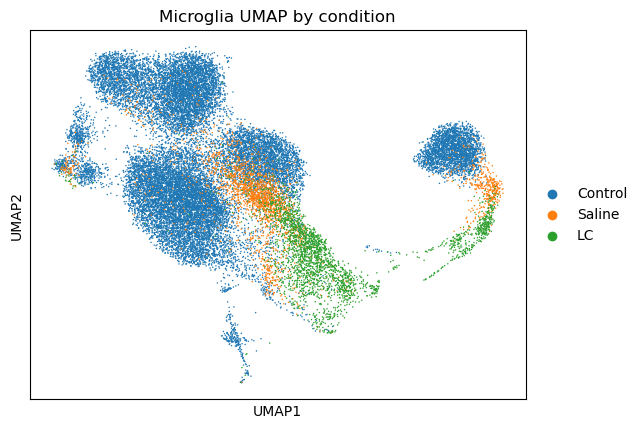

In [5]:
sc.pl.umap(mg_ad, color=['Condition'], title = "Microglia UMAP by condition")

In [6]:
# Integrate data
adata = mg_ad.copy()
sc.external.pp.harmony_integrate(adata, key='batch')
sc.pp.neighbors(adata, use_rep='X_pca_harmony')
sc.tl.umap(adata)

2025-07-10 16:33:55,788 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-07-10 16:34:05,507 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-07-10 16:34:05,612 - harmonypy - INFO - Iteration 1 of 10
2025-07-10 16:34:14,304 - harmonypy - INFO - Iteration 2 of 10
2025-07-10 16:34:21,183 - harmonypy - INFO - Converged after 2 iterations


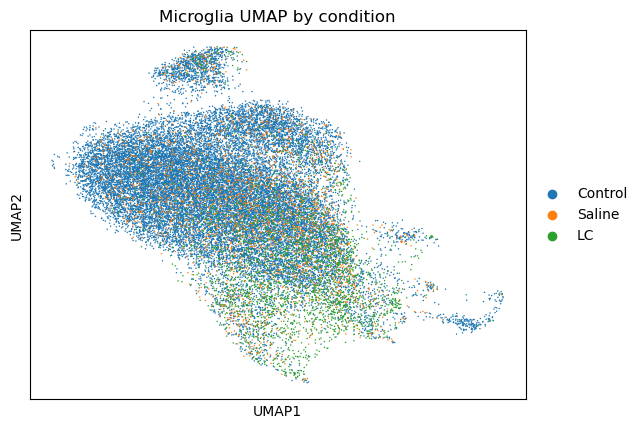

In [7]:
sc.pl.umap(adata, color=['Condition'], title = "Microglia UMAP by condition")

### DEA

In [27]:
resolution = 0.3
sc.tl.leiden(
    adata,
    resolution=resolution,
    flavor="igraph",
    n_iterations=5,
    key_added=f"leiden_res_{resolution}"
    )

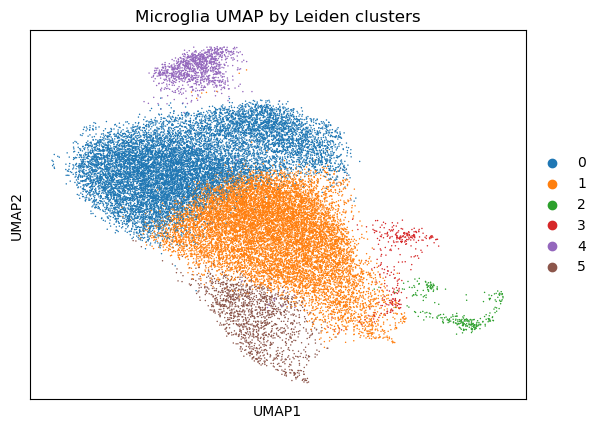

In [28]:
sc.pl.umap(adata, color=[f"leiden_res_{resolution}"], title = "Microglia UMAP by Leiden clusters")

In [29]:
sc.tl.rank_genes_groups(
    adata,
    groupby=f"leiden_res_{resolution}",
    method="wilcoxon",
    key_added = f"rank_genes_res_{resolution}",
    use_raw=True
)

### Identifying number of clusters

In [30]:
# Show the number of cells in each identified cluster
cluster_counts = adata.obs[f"leiden_res_{resolution}"].value_counts().sort_index()
print(cluster_counts)

leiden_res_0.3
0    12467
1    11612
2      286
3      306
4     1126
5     1380
Name: count, dtype: int64


In [31]:
def filter_degs_all_classes(adata, rank_genes_key, logfc_thresh=1.0, fdr_thresh=0.05, absolute_logfc=True):
    """
    Return a dictionary of DataFrames of DEGs for all classes passing logFC and FDR thresholds.
    Args:
        adata: AnnData object with rank_genes_groups results.
        logfc_thresh: Minimum absolute log2 fold change.
        fdr_thresh: Maximum adjusted p-value (FDR).
    Returns:
        Dictionary with class names as keys and DataFrames as values.
    """
    rg = adata.uns[rank_genes_key]
    classes = rg["names"].dtype.names
    degs_dict = {}
    for cls in classes:
        genes = rg["names"][cls]
        logfc = rg["logfoldchanges"][cls]
        pvals_adj = rg["pvals_adj"][cls]
        df = pd.DataFrame({
            "gene": genes,
            "logFC": logfc,
            "pval_adj": pvals_adj
        })
        if absolute_logfc:
            mask = (df["pval_adj"] < fdr_thresh) & (abs(df["logFC"]) > logfc_thresh)
        else:
            mask = (df["pval_adj"] < fdr_thresh) & (df["logFC"] > logfc_thresh)
        degs_dict[cls] = df[mask].reset_index(drop=True)
    return degs_dict

In [32]:
sig_DEGs_dict = filter_degs_all_classes(
    adata,
    rank_genes_key=f"rank_genes_res_{resolution}",
    logfc_thresh=1.0,
    fdr_thresh=0.01,
    absolute_logfc=True
    )
for key, df in sig_DEGs_dict.items():
    print(f"Cluster {key} at resolution {resolution}: {len(df)} significant DEGs")

Cluster 0 at resolution 0.3: 170 significant DEGs
Cluster 1 at resolution 0.3: 50 significant DEGs
Cluster 2 at resolution 0.3: 371 significant DEGs
Cluster 3 at resolution 0.3: 118 significant DEGs
Cluster 4 at resolution 0.3: 2 significant DEGs
Cluster 5 at resolution 0.3: 181 significant DEGs


In [33]:
def plot_cluster_marker_heatmap(
    adata,
    cluster_key,
    n_genes=10,
    scale=True,
    figsize=(10, 8),
    cmap="vlag",
    save_path=None,
    rank_genes_key=None
):
    """
    Plot a heatmap of scaled mean expression of top marker genes for each cluster.

    Args:
        adata: AnnData object.
        cluster_key: str, column in adata.obs for cluster labels.
        n_genes: int, number of top marker genes per cluster.
        scale: bool, whether to z-score scale genes across clusters.
        figsize: tuple, figure size.
        cmap: str, colormap.
        save_path: str or None, path to save figure.
        rank_genes_key: str or None, key in adata.uns for ranked genes (e.g. 'rank_genes_res_0.20').
    """
    if rank_genes_key is None:
        raise ValueError("Please provide rank_genes_key (e.g. 'rank_genes_res_0.20').")

    # Get top marker genes from adata.uns
    rank_genes = adata.uns[rank_genes_key]["names"]
    clusters = rank_genes.dtype.names
    top_genes = []
    for cl in clusters:
        top_genes.extend(rank_genes[cl][:n_genes])
    top_genes = list(dict.fromkeys(top_genes))  # remove duplicates, preserve order

    # Compute mean expression per cluster for these genes
    cluster_labels = adata.obs[cluster_key].unique()
    cluster_labels = sorted(cluster_labels, key=lambda x: str(x))
    expr = adata[:, top_genes].X
    if hasattr(expr, "toarray"):
        expr = expr.toarray()
    expr_df = pd.DataFrame(expr, index=adata.obs[cluster_key], columns=top_genes)
    mean_expr = expr_df.groupby(level=0, observed=False).mean().reindex(cluster_labels)

    # Optionally scale (z-score) genes across clusters
    if scale:
        mean_expr = (mean_expr - mean_expr.mean(axis=0)) / mean_expr.std(axis=0)
        vmin, vmax = -2, 2
    else:
        vmin = vmax = None

    # Plot clustered heatmap
    g = sns.clustermap(
        mean_expr.T,
        figsize=figsize,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        row_cluster=True,
        col_cluster=True,
        xticklabels=True,
        yticklabels=False,
        cbar_kws={"label": "Scaled mean expression" if scale else "Mean expression"}
    )
    g.ax_heatmap.set_xlabel("Cluster")
    g.ax_heatmap.set_xticklabels(
        g.ax_heatmap.get_xticklabels(),
        rotation=30,
        ha='right'
    )
    g.ax_heatmap.set_ylabel("Gene")
    plt.title("")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

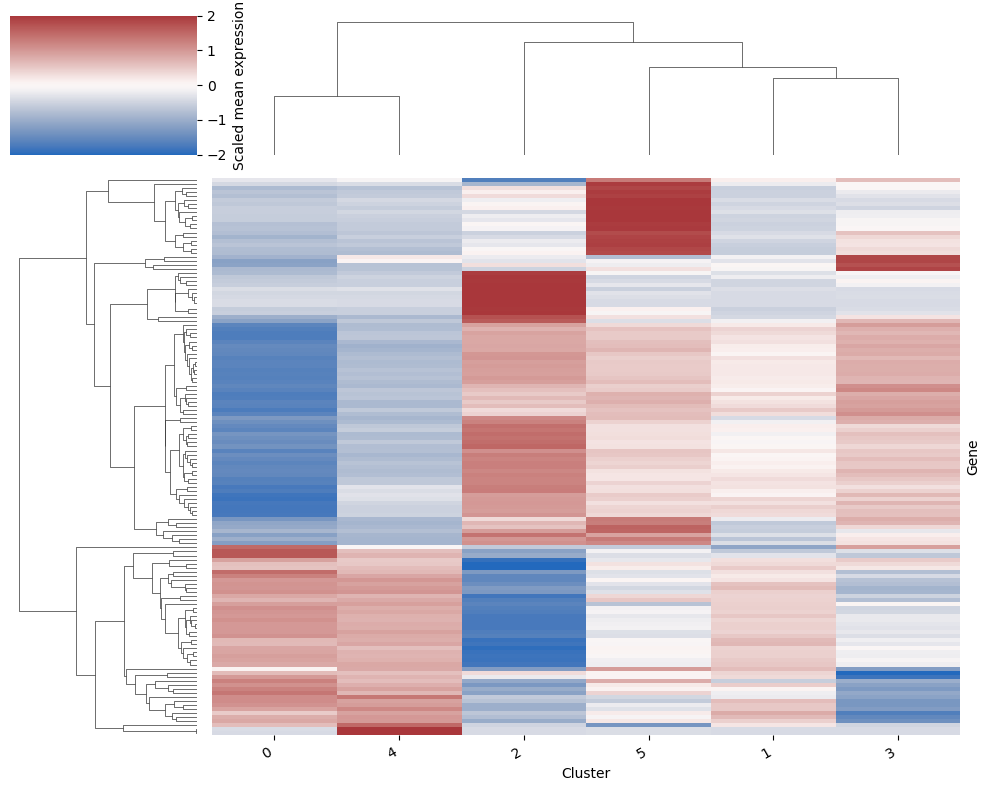

In [38]:
plot_cluster_marker_heatmap(
    adata,
    cluster_key = f"leiden_res_{resolution}",
    n_genes=30,
    scale=True,
    figsize=(10, 8),
    cmap="vlag",
    save_path="figures/Hammond_DEA_marker_heatmap.svg",
    rank_genes_key= f"rank_genes_res_{resolution}"
)

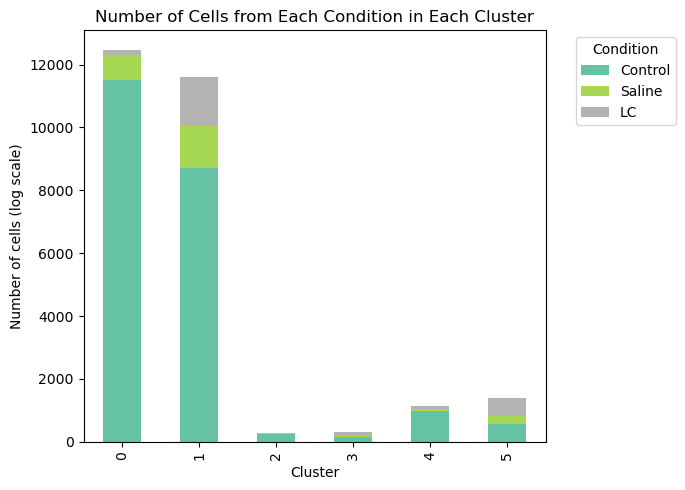

In [40]:
# Create a contingency table of cluster vs condition (counts)
# Create a contingency table of cluster vs condition
cluster_key = f"leiden_res_{resolution}"
contingency = pd.crosstab(adata.obs[cluster_key], adata.obs["Condition"], normalize=False)

# Plot stacked bar plot with logarithmic y-axis
ax = contingency.plot(kind='bar', stacked=True, figsize=(7, 5), colormap='Set2')
# ax.set_yscale('log')
plt.ylabel('Number of cells (log scale)')
plt.xlabel('Cluster')
plt.title('Number of Cells from Each Condition in Each Cluster')
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

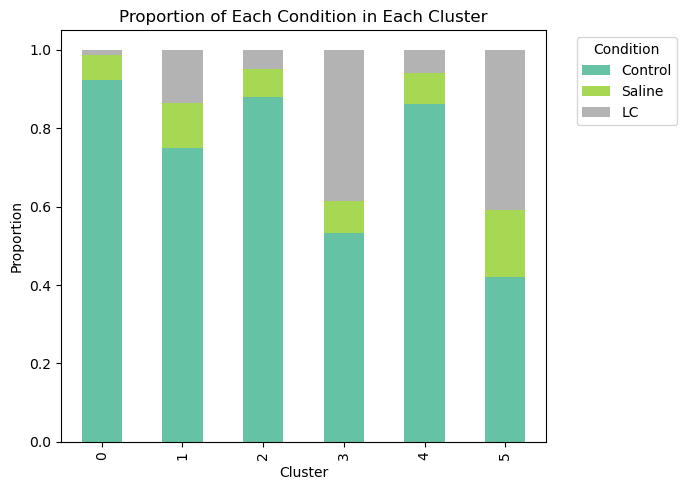

In [41]:
# Create a contingency table of cluster vs condition
cluster_key = f"leiden_res_{resolution}"
contingency = pd.crosstab(adata.obs[cluster_key], adata.obs["Condition"], normalize='index')

# Plot stacked bar plot
contingency.plot(kind='bar', stacked=True, figsize=(7, 5), colormap='Set2')
plt.ylabel('Proportion')
plt.xlabel('Cluster')
plt.title('Proportion of Each Condition in Each Cluster')
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

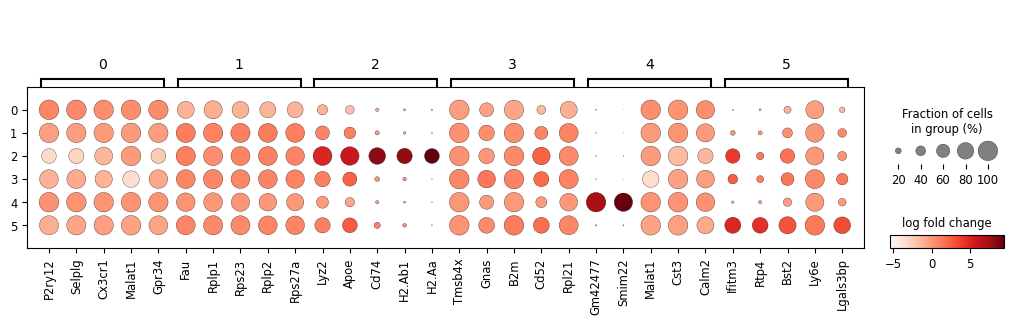

In [43]:
sc.pl.rank_genes_groups_dotplot(adata,
                                n_genes=5,
                                dendrogram=False,
                                values_to_plot="logfoldchanges",
                                key = f"rank_genes_res_{resolution}",
                                # cmap = "viridis"
                                # min_logfoldchange=1,
                                save="Hammond_DEA_markers.svg"
                                )

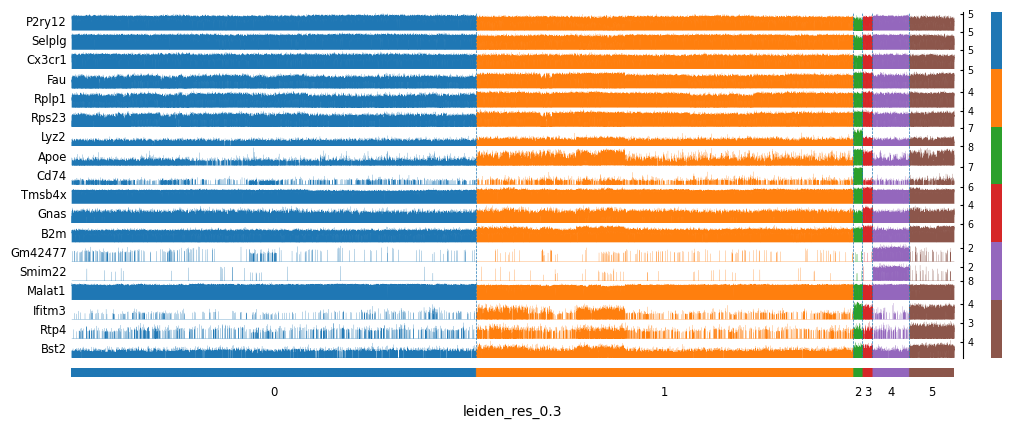

In [44]:
sc.pl.rank_genes_groups_tracksplot(adata,
                                   # groups = ["01 IT-ET Glut"],
                                   n_genes=3,
                                   dendrogram=False,
                                   show = True,
                                   key = f"rank_genes_res_{resolution}",
                                   # save="_Isoctx.png",
                                   )

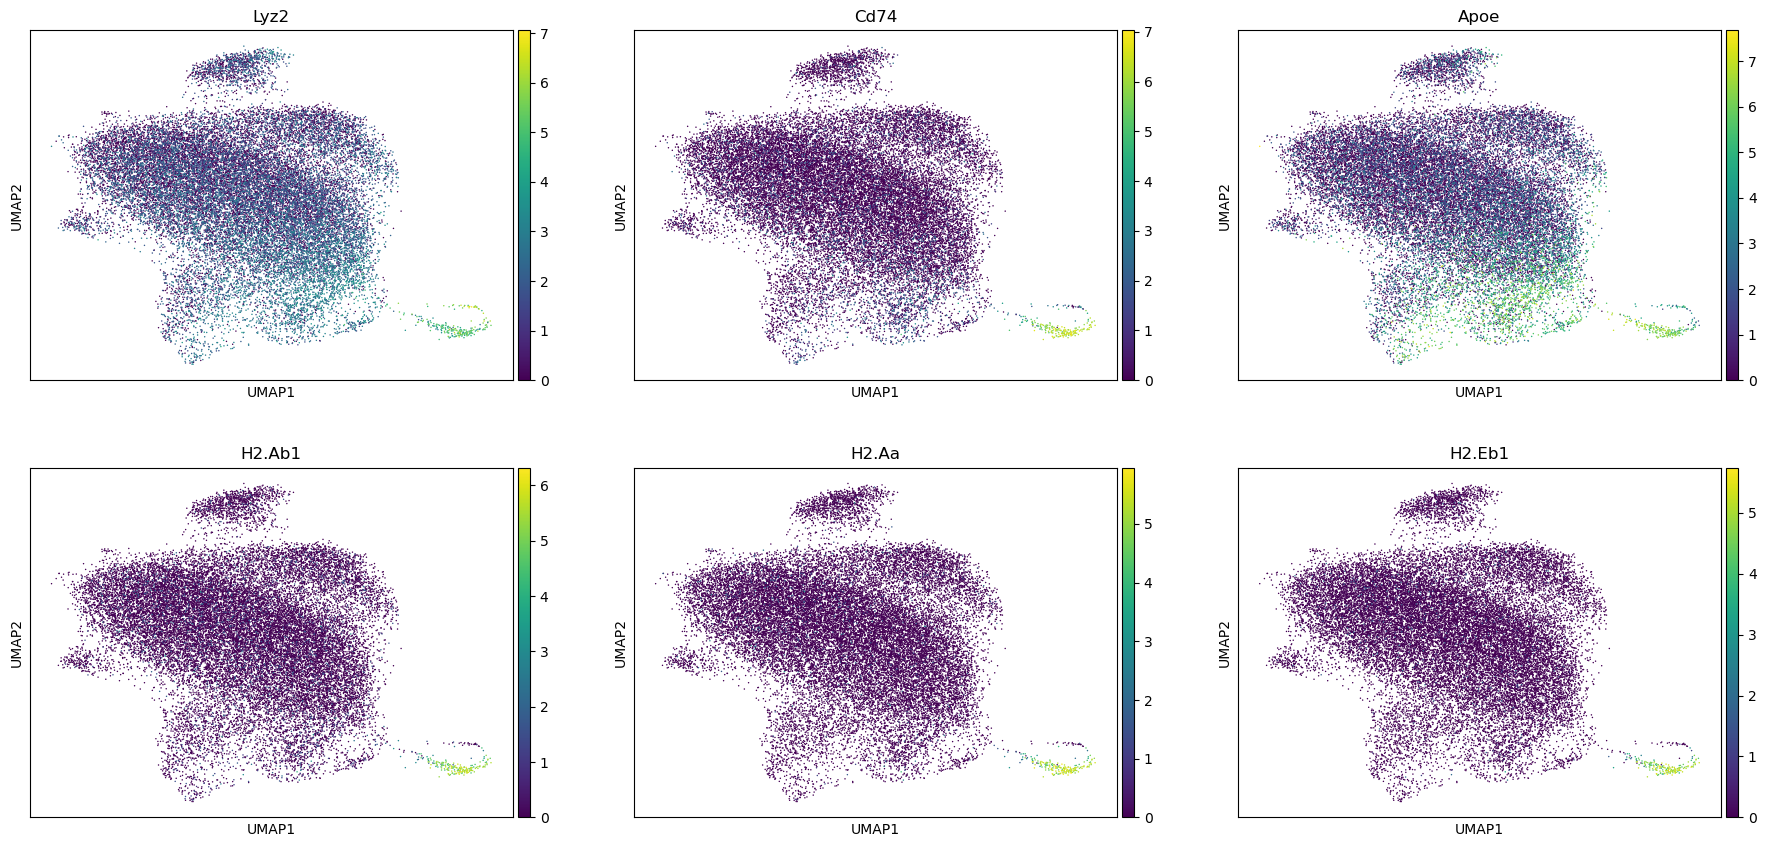

In [49]:
# Select a group and get the top 5 genes
group = "2"
top_genes = adata.uns[f"rank_genes_res_{resolution}"]["names"][group][:6]

sc.pl.umap(adata, color=top_genes, ncols=3)

In [ ]:
def compute_tau_scores(adata, cluster, n_genes, rank_genes_key, cluster_key):
        """
        Compute Tau specificity scores for the top n genes of a given cluster.

        Args:
                adata: AnnData object.
                cluster: str or int, cluster label.
                n_genes: int, number of top genes to consider.
                rank_genes_key: str, key in adata.uns for ranked genes (e.g. 'rank_genes_res_0.3').
                cluster_key: str, column in adata.obs for cluster labels.

        Returns:
                pd.DataFrame with columns ['Gene', 'Tau Score'].
        """
        # Get top n genes for the cluster
        top_genes = adata.uns[rank_genes_key]["names"][str(cluster)][:n_genes]

        # Compute mean expression per cluster for these genes
        expr = adata[:, top_genes].X
        if hasattr(expr, "toarray"):
                expr = expr.toarray()
        expr_df = pd.DataFrame(expr, index=adata.obs[cluster_key], columns=top_genes)
        mean_expr = expr_df.groupby(level=0, observed=False).mean()

        # Compute Tau score for each gene (normalized between 0 and 1)
        tau_scores = {}
        n_clusters = mean_expr.shape[0]
        for gene in top_genes:
                x = mean_expr[gene].values
                x_max = x.max()
                if x_max > 0 and n_clusters > 1:
                        # Ensure x/x_max is clipped between 0 and 1 to avoid negative values due to floating point errors
                        tau = np.sum(1 - np.clip(x / x_max, 0, 1)) / (n_clusters - 1)
                        # Clip tau to [0, 1] to avoid floating point overflow
                        tau = np.clip(tau, 0, 1)
                else:
                        tau = 0
                tau_scores[gene] = tau

        return pd.DataFrame(list(tau_scores.items()), columns=["Gene", "Tau Score"])

In [64]:
# Prompt for cluster name and number of genes
cluster_name = "2"  # Example cluster name
n_genes = 5

# Compute Tau scores
tau_scores_df = compute_tau_scores(adata, cluster_name, n_genes, f"rank_genes_res_{resolution}", f"leiden_res_{resolution}")
print(tau_scores_df)

     Gene  Tau Score
0    Lyz2   0.940030
1    Cd74   0.984004
2    Apoe   0.881474
3  H2.Ab1   0.996225
4   H2.Aa   1.000000


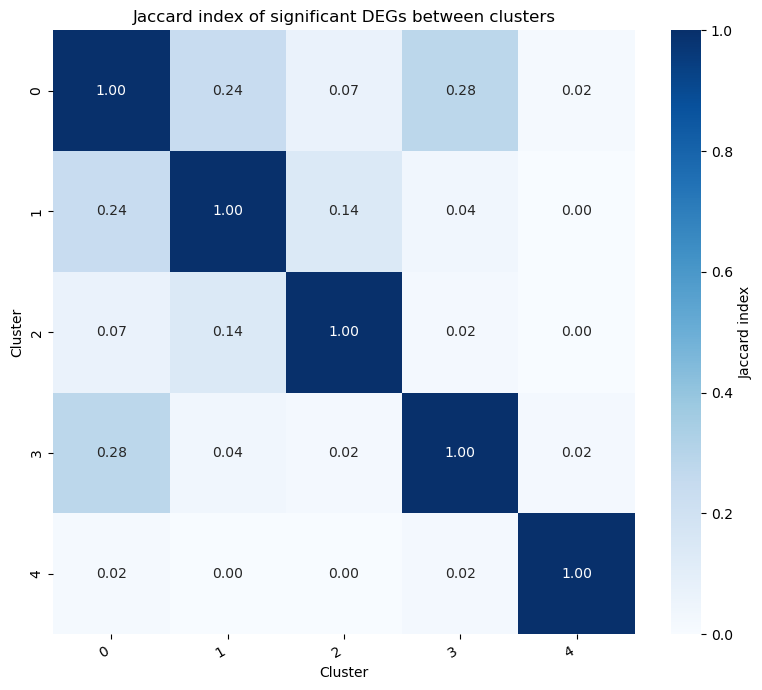

In [65]:
# Compute Jaccard index heatmap between marker sets from sig_DEGs_dict

# Get cluster names and marker sets
clusters = list(sig_DEGs_dict.keys())
n_clusters = len(clusters)
marker_sets = {cls: set(df["gene"]) for cls, df in sig_DEGs_dict.items()}

# Compute Jaccard index matrix
jaccard_matrix = np.zeros((n_clusters, n_clusters), dtype=float)
for i, cls1 in enumerate(clusters):
    for j, cls2 in enumerate(clusters):
        set1 = marker_sets[cls1]
        set2 = marker_sets[cls2]
        union = set1 | set2
        intersection = set1 & set2
        if len(union) == 0:
            jaccard_matrix[i, j] = np.nan
        else:
            jaccard_matrix[i, j] = len(intersection) / len(union)

# Plot heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(
    jaccard_matrix,
    xticklabels=clusters,
    yticklabels=clusters,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Jaccard index"}
)
plt.xticks(rotation=30, ha="right")
plt.title("Jaccard index of significant DEGs between clusters")
plt.xlabel("Cluster")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

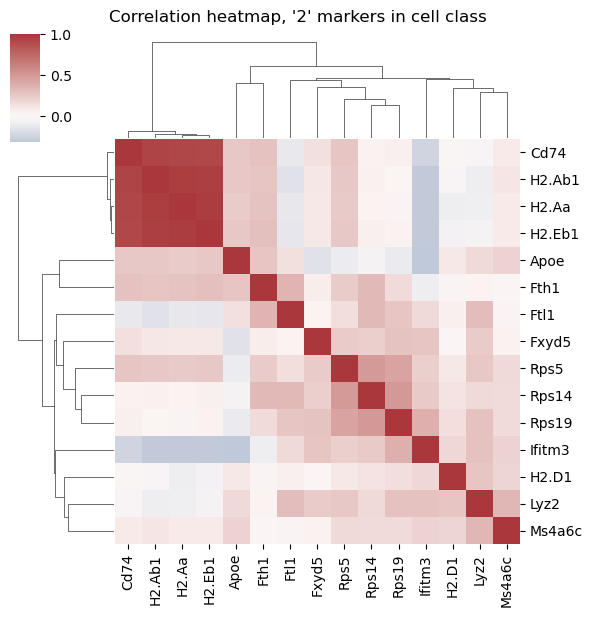

In [69]:
# Option: restrict correlation to cells of a specific class
restrict_to_class = True  # Set to True to use only cells of the target class
target_class = "2"
all_genes = False
rank_genes_key = f"rank_genes_res_{resolution}"
select_genes = adata.uns[rank_genes_key]["names"][str(target_class)][:15]
group_by = f"leiden_res_{resolution}"  # Column in adata.obs to group cells by class

# Extract expression matrix for significant DEGs
if all_genes:
    genes = adata.var_names.tolist()
elif select_genes is not None:
    genes = select_genes.tolist()
else:
    genes = sig_DEGs_dict[target_class]["gene"].tolist()


if restrict_to_class:
    cell_mask = adata.obs[group_by] == target_class
    expr_subset = adata[cell_mask, genes].X
    if hasattr(expr_subset, "toarray"):
        expr_subset = expr_subset.toarray()
    corr_matrix = np.corrcoef(expr_subset.T)
    title = f"Correlation heatmap, '{target_class}' markers in cell class"
else:
    expr = adata[:, genes].X
    if hasattr(expr, "toarray"):
        expr = expr.toarray()
    corr_matrix = np.corrcoef(expr.T)
    title = f"Correlation heatmap of \"{target_class}\" markers"

sns.clustermap(
    corr_matrix,
    row_cluster=True,
    col_cluster=True,
    xticklabels=genes,
    yticklabels=genes,
    cmap="vlag",
    center=0,
    figsize=(6, 6)
)
plt.suptitle(title, y=1.02)
# plt.savefig(f"figures/heatmap_correlation_{target_class}.svg")
plt.show()

In [45]:
from gprofiler import GProfiler

# Parameters
organism = "mmusculus"  # Use "hsapiens" for human

gp = GProfiler(return_dataframe=True)
go_enrichment_results = []

for cluster, df in sig_DEGs_dict.items():
    # Use all marker genes for this cluster
    marker_genes = df["gene"].dropna().tolist()
    if not marker_genes:
        print(f"Skipping cluster {cluster}: no markers found.")
        continue

    # Run GO enrichment
    enrichment_result = gp.profile(
        organism=organism,
        query=marker_genes,
        sources=["GO:BP"]  # Biological Process
    )
    enrichment_result["cluster"] = cluster
    go_enrichment_results.append(enrichment_result)

# Combine all results into a single DataFrame
go_results_df = pd.concat(go_enrichment_results, ignore_index=True)
go_results_df.head()

/tmp/ipykernel_685282/3715912941.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  go_results_df = pd.concat(go_enrichment_results, ignore_index=True)


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,cluster
0,GO:BP,GO:0002181,cytoplasmic translation,6.246664e-75,True,"""The chemical reactions and pathways resulting...",167,137,51,25907,0.372263,0.305389,query_1,[GO:0006412],0
1,GO:BP,GO:0140236,translation at presynapse,2.994510e-48,True,"""Translation that occurs at the presynapse."" [...",51,137,28,25907,0.204380,0.549020,query_1,[GO:0140241],0
2,GO:BP,GO:0140242,translation at postsynapse,6.461701e-48,True,"""Translation that occurs at the postsynapse."" ...",52,137,28,25907,0.204380,0.538462,query_1,[GO:0140241],0
3,GO:BP,GO:0140241,translation at synapse,6.461701e-48,True,"""Translation that occurs at the synapse."" [PMI...",52,137,28,25907,0.204380,0.538462,query_1,[GO:0006412],0
4,GO:BP,GO:0006412,translation,1.116550e-44,True,"""The cellular metabolic process in which a pro...",716,137,54,25907,0.394161,0.075419,query_1,"[GO:0009059, GO:0010467, GO:0019538]",0


In [48]:
def plot_go_dotplot(go_results_df, top_n=3, classes_on_x_axis=True, save_path=None):
    # ---------------------------------------------
    # Select top N enriched terms per cluster
    # ---------------------------------------------
    top_terms_df = (
        go_results_df
        .sort_values("p_value")
        .groupby("cluster")
        .head(top_n)
        .copy()
    )

    # Shorten term names for better plotting
    top_terms_df["term_display"] = top_terms_df["name"].str.slice(0, 50)
    top_terms_df["-log10(p)"] = -np.log10(top_terms_df["p_value"] + 1e-300)

    # Optional: sort GO terms by frequency of appearance across clusters
    term_order = (
        top_terms_df["term_display"]
        .value_counts()
        .index.tolist()
    )

    # ---------------------------------------------
    # Axes assignment based on flag
    # ---------------------------------------------
    if classes_on_x_axis:
        x, y = "cluster", "term_display"
        figsize = (10, max(5, 0.4 * len(term_order)))
        xlabel, ylabel = "", ""  # optional: customize
        xtick_rotation = 45
    else:
        x, y = "term_display", "cluster"
        figsize = (max(10, 0.4 * len(term_order)), 8)
        xlabel, ylabel = "", ""
        xtick_rotation = 90

    # ---------------------------------------------
    # Create the Dot Plot
    # ---------------------------------------------
    plt.figure(figsize=figsize)
    sns.scatterplot(
        data=top_terms_df,
        x=x,
        y=y,
        size="intersection_size",
        hue="-log10(p)",
        sizes=(30, 300),
        palette="viridis",
        edgecolor="black",
        alpha=0.8,
    )

    plt.xticks(rotation=xtick_rotation, ha="right" if classes_on_x_axis else "center")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f"Top {top_n} enriched GO terms per group")

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()

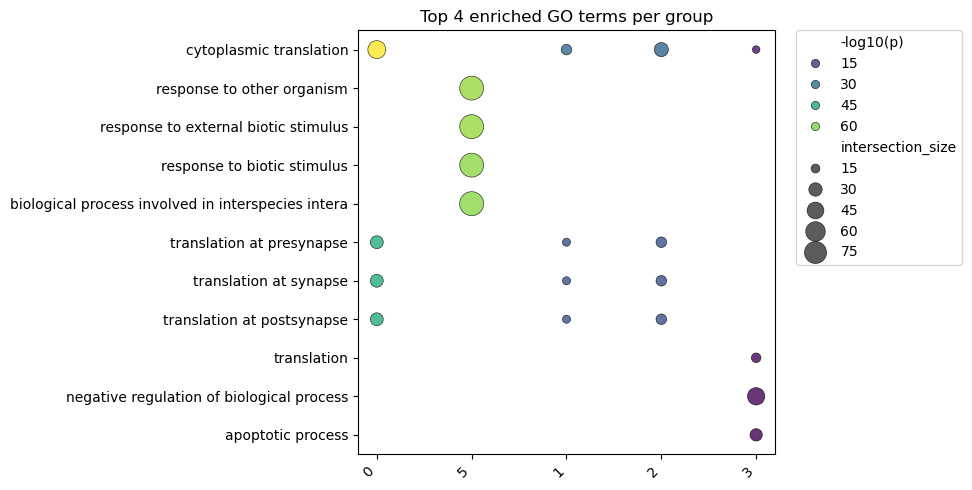

In [51]:
plot_go_dotplot(go_results_df,
                top_n=4,
                save_path="figures/dotplot_GO_Hammond_DEA_markers.svg",
                classes_on_x_axis=True)  # cluster on y-axis

In [91]:
microglia_gene_signatures = {
    "homeostatic": [
        "P2ry12", "Tmem119", "Cx3cr1", "Siglech", "Hexb", "Fcrls", 
        "Gpr34", "Olfml3", "Sall1", "Csf1r", "Cst3"
    ],
    "dam_stage1_upregulated": [
        "Tyrobp", "Apoe", "B2m", "Ctsb", "Ctsd"
    ],
    "dam_stage2_upregulated": [
        "Trem2", "Axl", "Itgax", "Cd9", "Cd63", "Csf1", "Ccl6", "C3",
        "Igf1", "Lyz2", "Cybb", "Lpl", "Cst7", "Ctsl", "Ctsz", 
        "Clec7a", "Lilrb4a", "Nmb", "Spp1", "Timp2"
    ],
    "dam_all_upregulated": [ # A combined list of all upregulated DAM genes
        "Tyrobp", "Apoe", "B2m", "Ctsb", "Ctsd", "Fth1", "Trem2", "Axl", "Itgax", 
        "Cd9", "Cd63", "Csf1", "Ccl6", "C3", "Igf1", "Lyz2", "Cybb", "Lpl", 
        "Cst7", "Ctsl", "Ctsz", "Clec7a", "Lilrb4a", "Nmb", "Spp1", "Timp2"
    ],
    "dam_downregulated": [ # These are essentially homeostatic genes
        "Tmem119", "P2ry12", "P2ry13", "Cx3cr1", "Cst3", "Cd33", "Csf1r"
    ],
    "ifn_response": [ # Type I Interferon Response Microglia
        "Ifit1", "Ifit3", "Ifitm3", "Isg15", "Oasl2", "Ch25h", "Irf7"
    ],
    "mhc_ii": [ # MHC-II Microglia
        "H2.Aa", "H2.Ab1", "H2.Eb1", "Cd74", "Hif1a"
    ],
    "arm": [ # Activated Response Microglia (largely overlaps with DAM)
        "Itgax", "Cst7", "Clec7a", "Cd74", "H2.Aa", "H2.Ab1", "Apoe", "Lpl"
    ],
    "proliferating": [
        "Mki67", "Top2a", "Pcna"
    ],
    "aging_associated": [ # General aging markers, includes ARM/DAM-like and IRM genes
        "Ccl3", "Ccl4", "Il1b", "Itgax", "Spp1", "Apoe", "Ifitm3", "Irf7",
        "Lpl", "Lgals3", "Cst7", "Clec7a", "H2.Aa", "H2.Ab1"
    ],
    "lps_induced_upregulated": [ # Acute inflammation model
        "Rplp0", "Rps2", "Cd52", "Cd63", "Ctsl", "Manf", "Pdia4", "Calm1", 
        "Fth1", "C5ar1", "Hacd2", "Gnl3"
    ],
    "nerve_injury_associated": [ # Markers associated with chronic nerve injury contexts
        "Apoe", "Spp1", "Lpl", "Atf3", "Gfap", "Vim", "Itgax", "Lgals3"
    ],
    "pan_microglial_markers": [ # General markers for identifying microglia
        "Itgam", "Aif1", "Cx3cr1", "Csf1r", "Ptprc"
    ]
}

In [96]:
# Check which genes in microglia_gene_signatures are missing from adata.var_names
missing_genes = {}
for signature, genes in microglia_gene_signatures.items():
    missing = [g for g in genes if g not in adata.var_names]
    if missing:
        missing_genes[signature] = missing

for signature, genes in missing_genes.items():
    print(f"Signature '{signature}' missing genes in adata: {genes}")

Signature 'dam_stage2_upregulated' missing genes in adata: ['C3', 'Clec7a']
Signature 'dam_all_upregulated' missing genes in adata: ['C3', 'Clec7a']
Signature 'ifn_response' missing genes in adata: ['Ch25h']
Signature 'arm' missing genes in adata: ['Clec7a']
Signature 'proliferating' missing genes in adata: ['Mki67', 'Top2a']
Signature 'aging_associated' missing genes in adata: ['Clec7a']
Signature 'nerve_injury_associated' missing genes in adata: ['Gfap']


In [97]:
def search_genes(keyword, adata):
    """
    Search for genes in adata.var_names containing the given keyword (case-insensitive).
    Returns a list of matching gene names.
    """
    keyword = keyword.lower()
    matches = [gene for gene in adata.var_names if keyword in gene.lower()]
    return matches

In [98]:
# Example usage:
genes_found = search_genes("gfa", adata)
print(genes_found)

['Pdgfa', 'Tgfa']


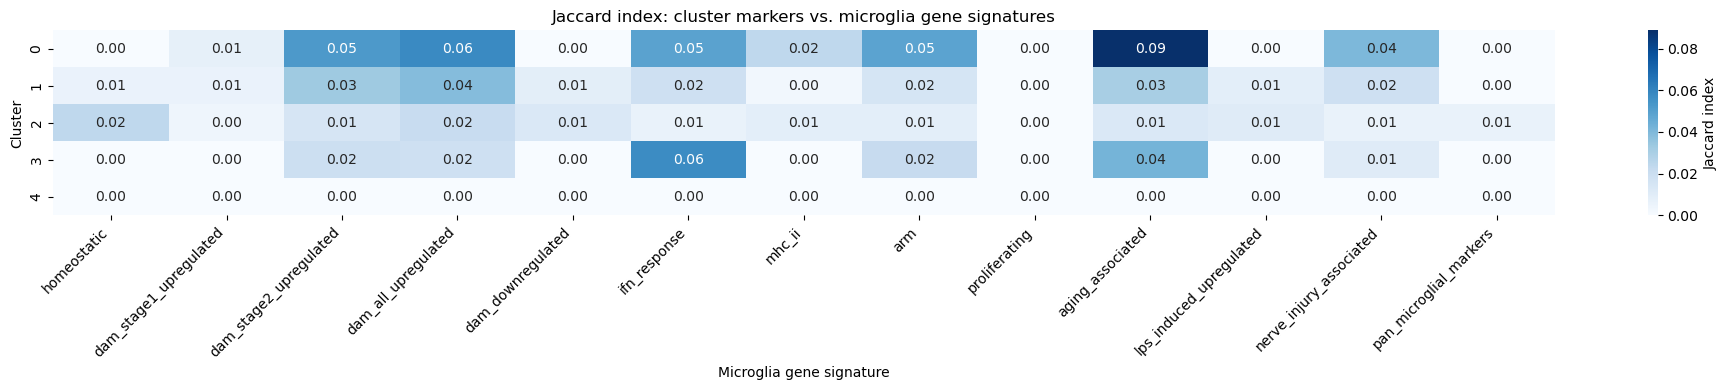

In [99]:
# Compute Jaccard index heatmap between cluster marker sets and microglia gene signatures

# Prepare sets
cluster_names = list(sig_DEGs_dict.keys())
signature_names = list(microglia_gene_signatures.keys())

# Build marker sets for clusters
cluster_marker_sets = {cls: set(df["gene"]) for cls, df in sig_DEGs_dict.items()}
# Build gene sets for signatures (only keep genes present in adata.var_names)
signature_sets = {
    sig: set([g for g in genes if g in adata.var_names])
    for sig, genes in microglia_gene_signatures.items()
}

# Compute Jaccard index matrix (clusters x signatures)
jaccard_mat = np.zeros((len(cluster_names), len(signature_names)), dtype=float)
for i, cls in enumerate(cluster_names):
    for j, sig in enumerate(signature_names):
        set1 = cluster_marker_sets[cls]
        set2 = signature_sets[sig]
        union = set1 | set2
        intersection = set1 & set2
        if len(union) == 0:
            jaccard_mat[i, j] = np.nan
        else:
            jaccard_mat[i, j] = len(intersection) / len(union)

# Plot heatmap
plt.figure(figsize=(1.5 * len(signature_names), 1 + 0.6 * len(cluster_names)))
sns.heatmap(
    jaccard_mat,
    xticklabels=signature_names,
    yticklabels=cluster_names,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Jaccard index"}
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Microglia gene signature")
plt.ylabel("Cluster")
plt.title("Jaccard index: cluster markers vs. microglia gene signatures")
plt.tight_layout()
plt.show()

In [103]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

def ora_between_clusters_and_signatures(sig_DEGs_dict, microglia_gene_signatures, background_genes=None, correction_method="fdr_bh"):
    """
    Perform over-representation analysis (Fisher's exact test) between cluster markers and microglia gene signatures.
    Prints warnings for unmatched gene names.
    Returns a DataFrame with results for all cluster-signature pairs, including multiple hypothesis correction.
    """
    results = []
    # Build background gene set
    if background_genes is None:
        marker_genes = set()
        for df in sig_DEGs_dict.values():
            marker_genes.update(df["gene"])
        signature_genes = set(g for genes in microglia_gene_signatures.values() for g in genes)
        background_genes = marker_genes | signature_genes

    for cluster, df in sig_DEGs_dict.items():
        cluster_genes = set(df["gene"])
        for sig_name, sig_genes in microglia_gene_signatures.items():
            sig_genes_set = set(sig_genes)
            unmatched_in_sig = [g for g in sig_genes_set if g not in background_genes]
            unmatched_in_cluster = [g for g in cluster_genes if g not in background_genes]
            if unmatched_in_sig:
                print(f"Signature '{sig_name}' - genes not in background: {unmatched_in_sig}")
            if unmatched_in_cluster:
                print(f"Cluster '{cluster}' - genes not in background: {unmatched_in_cluster}")

            overlap = cluster_genes & sig_genes_set
            a = len(overlap)
            b = len(cluster_genes - sig_genes_set)
            c = len(sig_genes_set - cluster_genes)
            d = len(background_genes - (cluster_genes | sig_genes_set))
            contingency = [[a, b], [c, d]]
            oddsratio, pval = fisher_exact(contingency, alternative="greater")
            results.append({
                "cluster": cluster,
                "signature": sig_name,
                "overlap": a,
                "cluster_size": len(cluster_genes),
                "signature_size": len(sig_genes_set),
                "background_size": 10570, #len(background_genes),
                "oddsratio": oddsratio,
                "pval": pval,
                "overlap_genes": ", ".join(sorted(overlap))
            })
    df_results = pd.DataFrame(results)
    # Multiple hypothesis correction
    if not df_results.empty:
        reject, pvals_corrected, _, _ = multipletests(df_results["pval"], method=correction_method)
        df_results["pval_adj"] = pvals_corrected
        df_results["significant"] = reject
    return df_results

In [102]:
len(adata.var_names)

10570

In [104]:
ora_results_df = ora_between_clusters_and_signatures(sig_DEGs_dict, microglia_gene_signatures)
ora_results_df.sort_values("pval").head(10)

,cluster,signature,overlap,cluster_size,signature_size,background_size,oddsratio,pval,overlap_genes,pval_adj,significant
9,0,aging_associated,11,122,14,10570,21.537538,2.290530e-07,"Apoe, Ccl3, Ccl4, Cst7, H2.Aa, H2.Ab1, Ifitm3,...",0.000015,True
5,0,ifn_response,6,122,7,10570,33.827586,8.221574e-05,"Ifit1, Ifit3, Ifitm3, Irf7, Isg15, Oasl2",0.002672,True
44,3,ifn_response,5,86,7,10570,21.265432,2.614562e-04,"Ifit3, Ifitm3, Irf7, Isg15, Oasl2",0.004656,True
7,0,arm,6,122,8,10570,16.887931,2.865364e-04,"Apoe, Cd74, Cst7, H2.Aa, H2.Ab1, Lpl",0.004656,True
26,2,homeostatic,11,457,11,10570,inf,2.771122e-03,"Csf1r, Cst3, Cx3cr1, Fcrls, Gpr34, Hexb, Olfml...",0.036025,True
11,0,nerve_injury_associated,5,122,8,10570,9.287749,3.327480e-03,"Apoe, Atf3, Lgals3, Lpl, Spp1",0.036048,True
22,1,aging_associated,10,324,14,10570,3.574841,2.310427e-02,"Apoe, Ccl3, Ccl4, Cst7, Ifitm3, Irf7, Itgax, L...",0.187282,False
18,1,ifn_response,6,324,7,10570,8.528302,2.315120e-02,"Ifit1, Ifit3, Ifitm3, Irf7, Isg15, Oasl2",0.187282,False
2,0,dam_stage2_upregulated,7,122,20,10570,3.006020,2.593139e-02,"Axl, Csf1, Cst7, Cybb, Lilrb4a, Lpl, Spp1",0.187282,False
6,0,mhc_ii,3,122,5,10570,8.231092,2.970023e-02,"Cd74, H2.Aa, H2.Ab1",0.193051,False


In [105]:
# Score each signature using scanpy's score_genes function
for signature_name, gene_list in microglia_gene_signatures.items():
    # Only keep genes present in adata.var_names
    genes_in_data = [g for g in gene_list if g in adata.var_names]
    if len(genes_in_data) == 0:
        print(f"Signature '{signature_name}': no genes found in adata.var_names, skipping.")
        continue
    sc.tl.score_genes(adata, gene_list=genes_in_data, score_name=f"{signature_name}_score", use_raw=False)
    print(f"Scored signature: {signature_name} ({len(genes_in_data)} genes)")

# The scores are now in adata.obs with columns like 'homeostatic_score', etc.
adata.obs[[f"{sig}_score" for sig in microglia_gene_signatures.keys() if f"{sig}_score" in adata.obs.columns]].head()

Scored signature: homeostatic (11 genes)
Scored signature: dam_stage1_upregulated (5 genes)
Scored signature: dam_stage2_upregulated (18 genes)
Scored signature: dam_all_upregulated (24 genes)
Scored signature: dam_downregulated (7 genes)
Scored signature: ifn_response (6 genes)
Scored signature: mhc_ii (5 genes)
Scored signature: arm (7 genes)
Scored signature: proliferating (1 genes)
Scored signature: aging_associated (13 genes)
Scored signature: lps_induced_upregulated (12 genes)
Scored signature: nerve_injury_associated (7 genes)
Scored signature: pan_microglial_markers (5 genes)


,homeostatic_score,dam_stage1_upregulated_score,dam_stage2_upregulated_score,dam_all_upregulated_score,dam_downregulated_score,ifn_response_score,mhc_ii_score,arm_score,proliferating_score,aging_associated_score,lps_induced_upregulated_score,nerve_injury_associated_score,pan_microglial_markers_score
TTAGGACAGAGGGCTT-1-0,-2.808626,-1.834294,-1.161298,-1.262440,-2.913452,-0.400516,-0.694334,-0.483273,-0.354719,-0.583688,-0.713845,-0.590301,-2.097808
GGCGACTTCCAAATGC-1-0,0.137366,-0.383008,-0.154821,-0.215550,0.473026,-0.443599,-0.031459,-0.188553,-0.525597,-0.195889,0.140708,-0.098474,0.600789
TCATTACTCGTGGACC-1-0,-0.061073,-0.060980,-0.078099,-0.062236,0.374951,-0.285136,0.158661,-0.300204,1.808043,-0.178550,0.220985,-0.193396,0.502506
GCAAACTTCGGCGGTT-1-0,-0.713328,0.165103,0.350227,0.293656,-0.346188,2.830148,6.938455,3.769015,-0.381854,1.857023,0.428188,1.652963,-0.148000
GGAATAATCACAGGCC-1-0,0.066018,-0.398799,-0.230148,-0.280424,-0.230922,-0.379460,0.305347,-0.362198,-0.540095,-0.221088,-0.218980,-0.295679,-0.151898


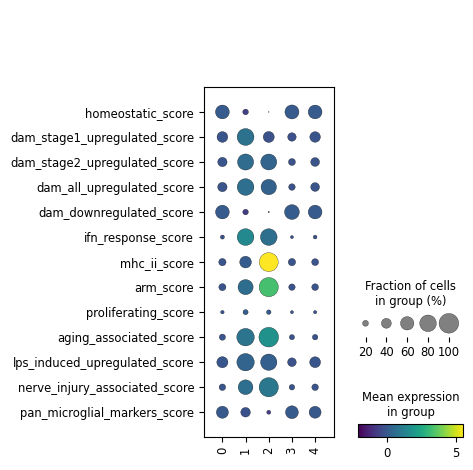

In [106]:
# Visualize gene set scores as a dotplot across clusters
score_cols = [f"{sig}_score" for sig in microglia_gene_signatures.keys() if f"{sig}_score" in adata.obs.columns]
cluster_col = f"leiden_res_{resolution}"

# Visualize gene set scores as a dotplot across clusters using scanpy's dotplot
sc.pl.dotplot(
    adata,
    var_names=score_cols,  # gene set score columns in .obs
    groupby=cluster_col,
    standard_scale=None,   # do not z-score, show raw scores
    use_raw=False,
    dot_max=None,
    color_map="viridis",
    swap_axes=True,        # signatures on y-axis, clusters on x-axis
    show=True
)